In [1]:
from collections import defaultdict
from irlc.ex09.mdp import MDP


class GridworldMDP(MDP):
    TERMINAL = "Terminal state"
    NORTH = 0   # These are the four available actions.
    EAST = 1
    SOUTH = 2
    WEST = 3
    actions2labels = {NORTH: 'North',
                      SOUTH: 'South',
                      EAST: 'East',
                      WEST: 'West'}  # This dictionary is useful for labelling purposes but otherwise serve no purpose.

    def __init__(self, grid, living_reward=0.0, noise=0.0, rand_noise=0.0):
        self.grid = {}
        self.height = len(grid)
        self.width = len(grid[0])
        initial_state = None
        for dy, line in enumerate(grid):
            y = self.height - dy - 1
            for x, el in enumerate(line):
                self.grid[x, y] = el
                if el == 'S':
                    initial_state = (x, y)
        self.noise = noise
        self.rand_noise = rand_noise

        self.living_reward = living_reward
        super().__init__(initial_state=initial_state)

    def A(self, state):
        """
        Returns list of valid actions available in 'state'.

        You can try to go into walls (but will state in your location)
        and when you are on the exit-squares (i.e., the ones with numbers), you have a single action available
        'North' which will take you to the terminal square.
        """
        return (self.NORTH,) if type(self.grid[state]) in [int, float] else (self.NORTH, self.EAST, self.SOUTH, self.WEST)

    def is_terminal(self, state):
        return state == self.TERMINAL

    def Psr(self, state, action):
        if type(self.grid[state]) in [float, int]:
            return {(self.TERMINAL, self.grid[state]): 1.}

        probabilities = defaultdict(float)
        for a, pr in [(action, 1-self.noise)] + [((a) % 4, self.noise/4) for a in range(4)]:
            sp = self.f(state, a)
            r = self.grid[state] if type(self.grid[state]) in [int, float] else self.living_reward
            probabilities[(sp, r)] += pr


        # for a, pr in [(action, 1-self.noise),  ((action - 1) % 4, self.noise/2), ((action + 1) % 4, self.noise/2)]:
        #     sp = self.f(state, a)
        #     r = self.grid[state] if type(self.grid[state]) in [int, float] else self.living_reward
        #     probabilities[(sp, r)] += pr
        return probabilities

    def f(self, state, action):
        x, y = state
        nxt = {self.NORTH: (x,   y+1),
               self.WEST:  (x-1, y),
               self.EAST:  (x+1, y),
               self.SOUTH: (x,   y-1)}
        return nxt[action] if self._legal(nxt[action]) else state

    def _legal(self, state):
        return state in self.grid and self.grid[state] != "#"


class FrozenGridMDP(GridworldMDP):
    def __init__(self, grid, is_slippery=True, living_reward=0):
        self.is_slippery = is_slippery
        super().__init__(grid, noise=2/3 if is_slippery else 0, living_reward=living_reward)

In [2]:
import numpy as np
from irlc.gridworld.gridworld_environments import GridworldEnvironment
from irlc import train, interactive
from irlc.ex11.q_agent import QAgent
from irlc.ex09.rl_agent import TabularQ
from irlc.utils.common import defaultdict2

class QuantileEstimator:
    def __init__(self, N, anneal=True):
        self.theta = np.linspace(0, 1, N)
        self.anneal = anneal
        self.steps = 0
        self.tau_hat = np.asarray([((i - 1) / N + i / N) / 2 for i in range(1, N + 1)])

    def ddtheta(self, Y, theta):
        u = Y[:,None] - theta[None,:]
        g = -(self.tau_hat - (u < 0)).mean(0)
        # S = len(Y)
        # g = np.zeros((len(theta),))
        # for y in Y:
        #     for i, tt in enumerate(theta):
        #         u = y - theta[i]
        #         g[i] += 1 / S * (-1) * (self.tau_hat[i] - (u < 0))
        return g

    def mean(self):
        return np.mean(self.theta)

    def learn(self, Y, alpha):
        lr = alpha * 1/ np.sqrt(self.steps +1) if self.anneal else alpha
        g = self.ddtheta(Y, self.theta)
        self.theta = self.theta - lr * g
        self.steps += 1

class QuantileQFunction(TabularQ):
    def __init__(self, env, N, anneal=True):
        super().__init__(env)
        def mkQ():
            return QuantileEstimator(N, anneal=anneal)

        def q_default(s):
            if s in self._known_masks:
                return {a: mkQ() for a in range(self.env.action_space.n) if self._known_masks[s][a - self.env.action_space.start] == 1}
            else:
                return {a: mkQ() for a in range(self.env.action_space.n)}

        self.q_ = defaultdict2(lambda s: q_default(s))


    def get_Qs(self, state, info_s=None):
        a, qs = super().get_Qs(state, info_s=info_s)
        return a, tuple([q.mean() for q in qs]) # convert to get mean.

    def __setitem__(self, state_comma_action, q_value):
        assert False, "Does not allow assignment!"

    def to_dict(self):
        d = {s: {a: Q.mean() for a, Q in Qs.items()} for s, Qs in self.q_.items()}
        return d

class QuantileAgent(QAgent):
    def __init__(self, env, N=20, gamma=1.0, alpha=0.2, epsilon=0.1, anneal=True):
        super().__init__(env, gamma, epsilon)
        self.alpha = alpha
        self.N = N
        self.Q = QuantileQFunction(env, N, anneal=anneal)

    def train(self, s, a, r, sp, done=False, info_s=None, info_sp=None):
        if self.alpha == 0:
            return
        if not done:
            a_star = self.Q.get_optimal_action(sp, info_sp)


        targets = r + self.gamma * (np.zeros((self.N,)) if done else self.Q[sp, a_star].theta )
        self.Q[s, a].learn(targets, self.alpha)

grid_cliff_grid3 = [[' ',' ',' ',' '],
                    [' ',' ',' ',' '],
                    ['S', -1, -1, 1]]


class CliffGridEnvironmentNoise(GridworldEnvironment):
    def _get_mdp(self, grid, uniform_initial_state=False):
        return GridworldMDP(grid, living_reward=self.living_reward, noise=0.5)

    def __init__(self, *args, **kwargs):
        super().__init__(grid_cliff_grid3, living_reward=0, *args, **kwargs)

    def step(self, action):
        state, reward, terminated, truncaated, info = super().step(action)
        if abs(reward) > 0.0: reward += np.random.randn()/8
        return state, reward, terminated, truncaated, info

100%|██████████| 1000/1000 [00:02<00:00, 384.08it/s, Episode=990, Accumulated Reward=-1.05, Length=2, Steps=12119]


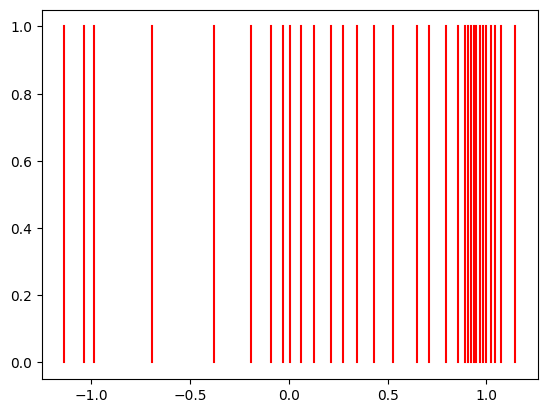

100%|██████████| 5000/5000 [00:09<00:00, 548.60it/s, Episode=4950, Accumulated Reward=-0.895, Length=4, Steps=55157] 
Number of bins used: 41
Bin edges: [-1.44593511 -1.37839466 -1.31085422 -1.24331378 -1.17577333 -1.10823289
 -1.04069245 -0.973152   -0.90561156 -0.83807111 -0.77053067 -0.70299023
 -0.63544978 -0.56790934 -0.5003689  -0.43282845 -0.36528801 -0.29774756
 -0.23020712 -0.16266668 -0.09512623 -0.02758579  0.03995465  0.1074951
  0.17503554  0.24257599  0.31011643  0.37765687  0.44519732  0.51273776
  0.5802782   0.64781865  0.71535909  0.78289954  0.85043998  0.91798042
  0.98552087  1.05306131  1.12060175  1.1881422   1.25568264  1.32322309]
Quantile tau=0.015625: index position = 78, value = -1.166073716884712
Quantile tau=0.046875: index position = 234, value = -1.0922741718113342
Quantile tau=0.078125: index position = 390, value = -1.0385689350279348
Quantile tau=0.109375: index position = 546, value = -0.994836279276085
Quantile tau=0.140625: index position = 703, va

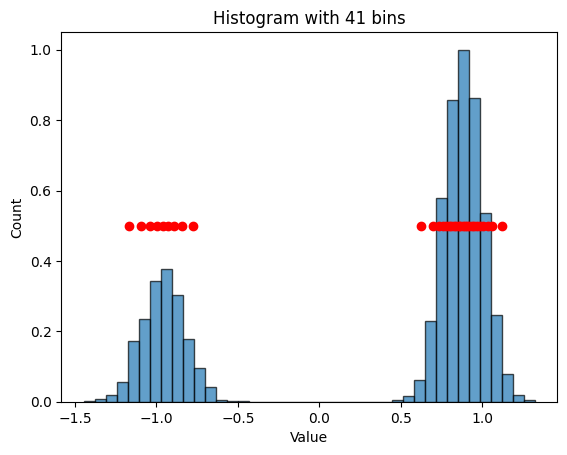

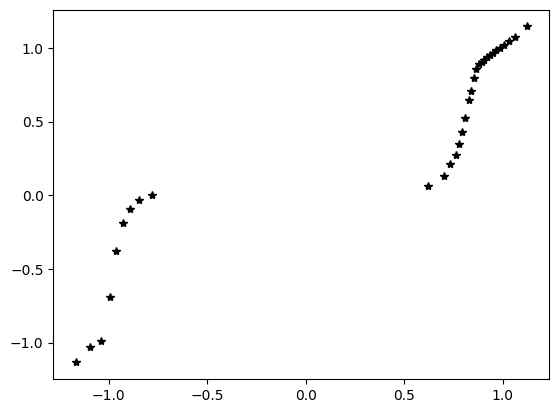

In [3]:
env = CliffGridEnvironmentNoise(render_mode=None)
gamma = 0.99
N = 32
agent = QuantileAgent(env, N=N, anneal=True, alpha=0.5, gamma=gamma, epsilon=0.35)
E = 1000
train(env, agent, num_episodes=E)

theta = agent.Q[(0, 0), 0].theta
import matplotlib.pyplot as plt
plt.plot( np.stack([theta, theta]) , np.stack([theta*0, theta*0+1]), 'r-')
plt.show()

agent.epsilon = 0
agent.alpha = 0
stats, traj = train(env, agent, num_episodes=E*5, return_trajectory=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

your_numbers = [ sum( [(gamma ** k * float(r) ) for k, r in enumerate(t.reward )] ) for t in traj]

X = np.array(your_numbers).reshape(-1, 1)

n_bins = 41

# Initialize KBinsDiscretizer with desired bin count and uniform strategy (equal-width bins)
kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')

# Fit and transform data into bin indices
bin_indices = kbd.fit_transform(X).astype(int).ravel()

# Count number of elements in each bin
counts = np.bincount(bin_indices, minlength=n_bins)
counts = [c / max(counts) for c in counts]
# Get bin edges from KBinsDiscretizer
bin_edges = kbd.bin_edges_[0]

# Plot histogram as bar chart aligned to bin edges
widths = np.diff(bin_edges)
plt.bar(bin_edges[:-1], counts, width=widths, align='edge', edgecolor='black', alpha=0.7)

print(f'Number of bins used: {n_bins}')
print('Bin edges:', bin_edges)


tau_hat= [ ( i +  (i+1) ) / (2*N) for i in range(N) ]

sorted_numbers = np.sort(your_numbers)

n = len(sorted_numbers)

# For each tau, compute the zero-based index in the sorted array corresponding to the quantile
positions = [min(int(np.floor(tau * n)), n - 1) for tau in tau_hat]

# Print results
for tau, pos in zip(tau_hat, positions):
    print(f"Quantile tau={tau}: index position = {pos}, value = {sorted_numbers[pos]}")

ypos = np.asarray([sorted_numbers[pos] for pos in positions])
plt.plot(ypos, ypos*0+0.5, 'ro')
plt.xlabel('Value')
plt.ylabel('Count')
plt.title(f'Histogram with {n_bins} bins')

plt.show()

plt.plot(ypos, theta, 'k*')
plt.show()
env.close()

In [20]:
traj[9].reward

[array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0),
 array(0.96841214)]